In [1]:
# ============================================================
# Differential Injection Attack (DIA) on CV-Deep2S
# ROI-weighted version (object-focused attack)
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from scipy.ndimage import label, binary_dilation

from src import src   # your provided src.py (UNets, wrappers, etc.)

np.random.seed(0)
tf.random.set_seed(0)

In [2]:
# ============================================================
# 1. Load observation model A and CV-Deep2S model
# ============================================================

# --- 1.1 Load physics-based observation model A ---
# A: (K, T, R, X, Y, Z)
A_path = "models/experimental/A15_exp.npy"
A = np.load(A_path)          # complex-valued array
print("A.shape =", A.shape)
K, T, R, X, Y, Z = A.shape

# --- 1.2 Load clean experimental measurements ---
# y_clean: (1, K, T, R)
y_path = "data/y_exp_test_4.npy"
y_exp = np.load(y_path)      # (K,T,R), complex
y_clean = y_exp[None, ...].astype(np.complex64)
print("y_clean.shape =", y_clean.shape)

# --- 1.3 Build CV-Deep2S UNet and load weights ---
# Input to CV-UNet: (X, Y, Z, 2)  [Re, Im of normalized A^H y]
DNN = src.get_CV_UNet(input_shape=(X, Y, Z, 2))
DNN.load_weights("models/experimental/CV-Deep2S/model_Nf15_SNR30_CV_exp.h5")
print("Loaded CV-Deep2S weights.")

A.shape = (15, 16, 9, 25, 25, 49)
y_clean.shape = (1, 15, 16, 9)
Loaded CV-Deep2S weights.


In [3]:
# ============================================================
# 2. TensorFlow constants for A and victim measurements load attack dictionary D_flat (X_a) in measurement domain
# ============================================================

A_tf      = tf.constant(A.astype(np.complex64))        # (K,T,R,X,Y,Z)
A_conj_tf = tf.math.conj(A_tf)

# Flatten victim measurements across aperture positions (T*R)
Np = T * R
X_v_flat = y_clean[0].reshape(K, Np)                   # (K, Np)
X_v_flat_tf = tf.constant(X_v_flat.astype(np.complex64))

D_flat_path = "data/D_flat.npy"       # (K, Np), complex64
D_flat_np = np.load(D_flat_path)
assert D_flat_np.shape == (K, Np)
D_flat = tf.constant(D_flat_np.astype(np.complex64))

print("D_flat.shape =", D_flat.shape)

D_flat.shape = (15, 144)


x_clean_mag.shape = (25, 25, 49)


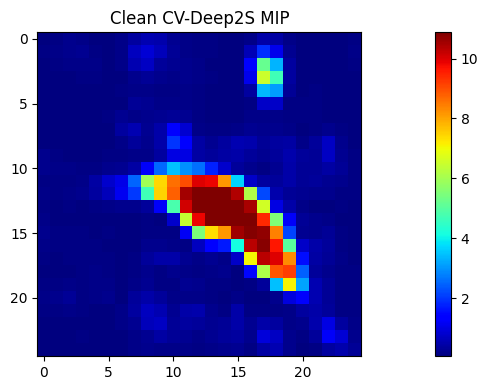

In [4]:
# ============================================================
# 3. CV-Deep2S forward operator implemented in TF
# ============================================================

def cv_deep2s_forward_tf(y_batch):
    """
    CV-Deep2S forward mapping in TensorFlow.

    Args
    ----
    y_batch : tf.Tensor, shape (N, K, T, R), complex64
        Batch of experimental measurements.

    Returns
    -------
    x_hat_mag : tf.Tensor, shape (N, X, Y, Z), float32
        RMS-normalized reconstructed magnitude volumes.
    """
    # 1) Adjoint physics: A^H y : (K,T,R,X,Y,Z) & (N,K,T,R) -> (N,X,Y,Z)
    AHy = tf.einsum('ktrxyz,Nktr->Nxyz', A_conj_tf, y_batch)  # complex64, (N,X,Y,Z)

    # 2) Per-sample max normalization (on magnitude, but applied to complex image)
    mag     = tf.abs(AHy)                                      # float32, (N,X,Y,Z)
    max_mag = tf.reduce_max(mag, axis=(1, 2, 3), keepdims=True)  # float32, (N,1,1,1)

    # Cast max_mag to complex so division is complex/complex
    max_mag_c = tf.cast(max_mag + 1e-12, tf.complex64)
    AHy_norm  = AHy / max_mag_c                                # complex64, (N,X,Y,Z)

    # 3) Form 2-channel (Re, Im) input to the CV-UNet
    AHy_ri = tf.stack(
        [tf.math.real(AHy_norm), tf.math.imag(AHy_norm)],
        axis=-1
    )  # (N,X,Y,Z,2), float32

    # 4) Pass through UNet prior
    x_hat = DNN(AHy_ri, training=False)   # (N,X,Y,Z,1) or (N,X,Y,Z)

    if tf.is_tensor(x_hat) and x_hat.dtype.is_complex:
        x_hat = tf.abs(x_hat)

    if len(x_hat.shape) == 5:
        x_hat = x_hat[..., 0]  # (N,X,Y,Z)

    # 5) RMS normalization to match MATLAB post-processing
    rms = tf.sqrt(tf.reduce_mean(x_hat**2, axis=(1, 2, 3), keepdims=True) + 1e-12)
    x_hat = x_hat / rms

    return x_hat  # (N,X,Y,Z), float32
    
x_clean_mag = cv_deep2s_forward_tf(tf.constant(y_clean)).numpy()[0]

print("x_clean_mag.shape =", x_clean_mag.shape)

# 2D MIP for quick visualization
clean_mip = x_clean_mag.max(axis=2)
plt.figure(figsize=(15,4))
plt.imshow(clean_mip, origin='upper', cmap='jet')
plt.title("Clean CV-Deep2S MIP")
plt.colorbar()
plt.tight_layout()
plt.show()

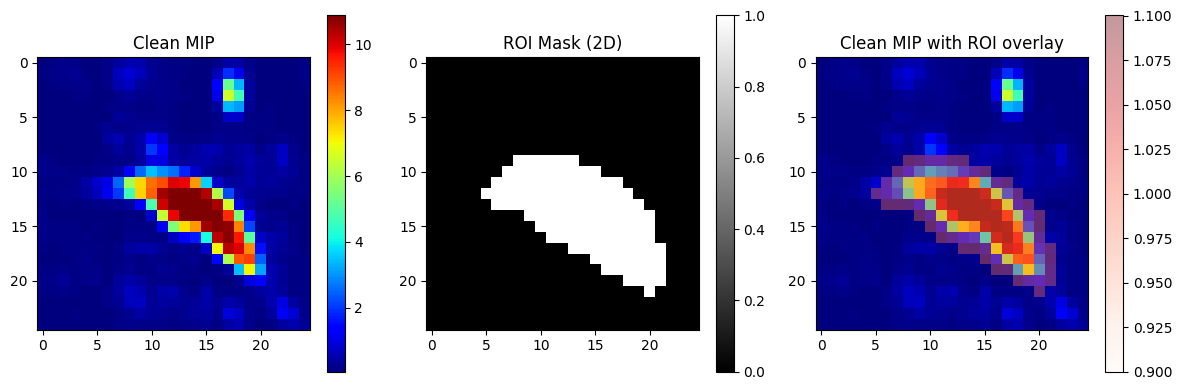

In [14]:
from scipy.ndimage import label, binary_dilation

# ============================================================
# 4.1 Automatic ROI mask around the brightest object (3D)
# ============================================================

clean_mip = x_clean_mag.max(axis=2)   # (X, Y)

# 1) Threshold to get bright region
thresh = .1 * clean_mip.max()       # tune 0.5–0.7 as needed
binary = clean_mip > thresh          # (X, Y) boolean

# 2) Connected components – keep largest blob
labels, num = label(binary)
if num == 0:
    raise RuntimeError("No bright region found for ROI!")

counts = np.bincount(labels.ravel())
largest_label = np.argmax(counts[1:]) + 1
obj_mask_2d = labels == largest_label   # (X, Y) *pixel-wise* object

# 3) Optional dilation so we don't miss fringe pixels
roi_2d = binary_dilation(obj_mask_2d, iterations=1)  # still (X, Y) boolean

# 4) Lift to 3D
roi_mask    = np.repeat(roi_2d[..., None], Z, axis=2)  # (X, Y, Z)
roi_mask_tf = tf.constant(roi_mask)                    # bool (X,Y,Z)


mask_2d = roi_mask[:, :, 0].astype(float)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(clean_mip, origin='upper', cmap='jet'); plt.title('Clean MIP'); plt.colorbar()

plt.subplot(1,3,2)
plt.imshow(mask_2d, origin='upper', cmap='gray'); plt.title('ROI Mask (2D)'); plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(clean_mip, origin='upper', cmap='jet')
plt.imshow(np.ma.masked_where(mask_2d == 0, mask_2d),
           origin='upper', cmap='Reds', alpha=0.4)
plt.title('Clean MIP with ROI overlay'); plt.colorbar()
plt.tight_layout(); plt.show()

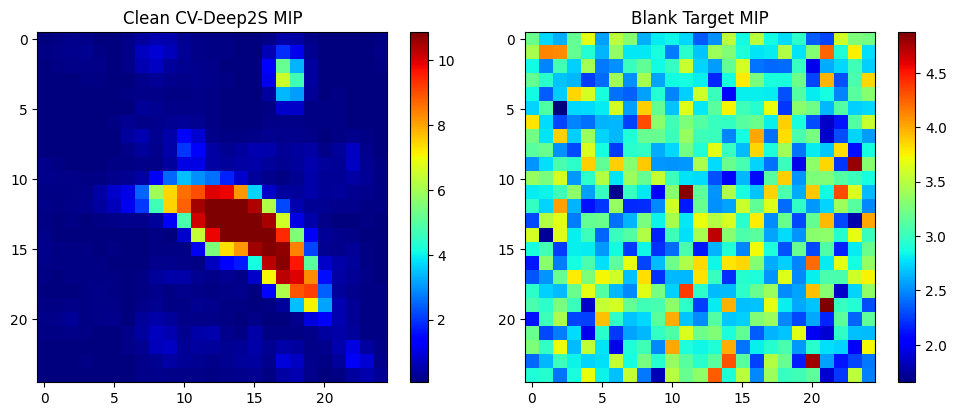

In [7]:
# ============================================================
# 5. Construct "blank" target volume (camouflage objective)
# ============================================================

clean_mip   = x_clean_mag.max(axis=2)
bg_val      = float(clean_mip[0, 0])                       # dark region
drange      = float(clean_mip.max() - clean_mip.min())

base = np.full((X, Y, Z), bg_val, dtype=np.float32)

np.random.seed(1234)
noise_std = 0.05 * drange                                  # 5% of range
noise     = noise_std * np.random.randn(X, Y, Z).astype(np.float32)

x_target = base + noise
x_target = np.clip(x_target, 0.0, None)

# RMS normalization
rms_tgt  = np.sqrt(np.mean(x_target**2) + 1e-12)
x_target = x_target / rms_tgt

x_target_tf  = tf.constant(x_target[None, ...])   # (1,X,Y,Z)
x_target_mip = x_target.max(axis=2)               # 2D MIP

# Visualize clean vs target
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(clean_mip, origin='upper', cmap='jet')
plt.title("Clean CV-Deep2S MIP")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(x_target_mip, origin='upper', cmap='jet')
plt.title("Blank Target MIP")
plt.colorbar()

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# 6. Attack loss: ROI-weighted image MSE + L2 on A
# ============================================================

def attack_loss(A_re, A_im, lambda_L2=0.0,
                roi_weight=1.0, bg_weight=0.0):
    """
    ROI-weighted attack objective:

      loss_im = roi_weight * MSE( x_att, x_target  over ROI )
              + bg_weight  * MSE( x_att, x_target  outside ROI )

      total   = loss_im + lambda_L2 * ||A||_2^2
    """
    # Complex gain vector A
    A_complex = tf.complex(A_re, A_im)          # (Np,)
    A_col     = tf.reshape(A_complex, (1, Np))  # (1,Np)

    # Attacked measurements (K,Np) -> (1,K,T,R)
    Y_flat  = X_v_flat_tf + D_flat * A_col      # (K,Np)
    Y_batch = tf.reshape(Y_flat, (1, K, T, R))

    # CV-Deep2S reconstruction
    x_hat_mag = cv_deep2s_forward_tf(Y_batch)   # (1,X,Y,Z)
    x_hat = x_hat_mag[0]                        # (X,Y,Z)
    x_tgt = x_target_tf[0]                      # (X,Y,Z)

    # ROI / background masks
    roi_mask_local = roi_mask_tf               # (X,Y,Z)
    bg_mask_local  = tf.logical_not(roi_mask_local)

    # ROI MSE
    roi_diff = tf.boolean_mask(x_hat - x_tgt, roi_mask_local)
    mse_roi  = tf.reduce_mean(roi_diff**2)

    # Background MSE (optional)
    bg_diff = tf.boolean_mask(x_hat - x_tgt, bg_mask_local)
    mse_bg  = tf.reduce_mean(bg_diff**2)

    loss_im = roi_weight * mse_roi + bg_weight * mse_bg

    # L2 regularization on A
    reg = lambda_L2 * tf.reduce_mean(tf.abs(A_complex)**2)

    return loss_im + reg, loss_im, reg, x_hat_mag


In [9]:
# ============================================================
# 8. DIA loop: optimize complex gains A via latent variables Z
# ============================================================

Amax      = 2.0        # physical amplitude bound on |A_p|
lambda_L2 = 1e-5       # L2 weight (tune 1e-4–1e-2 if needed)
max_iter  = 300        # number of iterations

# Latent variables; A = f(Z) via tanh parameterization
Z_re = tf.Variable(1e-3 * tf.random.normal(shape=(Np,), dtype=tf.float32))
Z_im = tf.Variable(1e-3 * tf.random.normal(shape=(Np,), dtype=tf.float32))

def get_A_from_Z(Z_re, Z_im, Amax=2.0):
    """
    Smooth parameterization so each component lies in
    [-Amax/sqrt(2), Amax/sqrt(2)], guaranteeing |A_p| <= Amax.
    """
    scale = Amax / np.sqrt(2.0)
    A_re = scale * tf.tanh(Z_re)
    A_im = scale * tf.tanh(Z_im)
    return A_re, A_im

# Adam with simple two-stage LR schedule
optimizer      = tf.keras.optimizers.Adam(learning_rate=1e-1)
lr_switch_iter = 100
low_lr         = 1e-2

loss_hist  = []
meanA_hist = []
maxA_hist  = []

print("\nStarting ROI-weighted DIA on CV-Deep2S (Np = {})...".format(Np))

for it in range(1, max_iter + 1):

    # Drop LR after lr_switch_iter
    if it == lr_switch_iter + 1:
        optimizer.learning_rate.assign(low_lr)
        print(f"\n[LR SCHEDULE] Switched Adam LR to {low_lr}\n")

    with tf.GradientTape() as tape:
        A_re_cur, A_im_cur = get_A_from_Z(Z_re, Z_im, Amax=Amax)
        loss_total, loss_im, reg, x_hat_mag = attack_loss(
            A_re_cur, A_im_cur,
            lambda_L2=lambda_L2,
            roi_weight=1.0,   # only ROI drives the loss
            bg_weight=0.0
        )

    grads = tape.gradient(loss_total, [Z_re, Z_im])
    optimizer.apply_gradients(zip(grads, [Z_re, Z_im]))

    # Logging stats
    A_re_val, A_im_val = get_A_from_Z(Z_re, Z_im, Amax=Amax)
    A_complex = tf.complex(A_re_val, A_im_val)
    A_now = A_complex.numpy()
    meanA = np.mean(np.abs(A_now))
    maxA  = np.max(np.abs(A_now))

    loss_hist.append(loss_total.numpy().item())
    meanA_hist.append(meanA)
    maxA_hist.append(maxA)

    if (it == 1) or (it % 5 == 0) or (it == max_iter):
        print(
            f"Iter {it:3d}/{max_iter:3d} | "
            f"Loss={loss_total.numpy():.6e} | "
            f"loss_im={loss_im.numpy():.6e} | reg={reg.numpy():.6e} | "
            f"mean|A|={meanA:.3e}, max|A|={maxA:.3e}"
        )

print("Attack optimization finished.")


Starting ROI-weighted DIA on CV-Deep2S (Np = 144)...
Iter   1/300 | Loss=4.900480e+00 | loss_im=4.900480e+00 | reg=4.336306e-11 | mean|A|=1.988e-01, max|A|=2.024e-01
Iter   5/300 | Loss=4.351706e+00 | loss_im=4.351703e+00 | reg=2.567960e-06 | mean|A|=5.649e-01, max|A|=9.107e-01
Iter  10/300 | Loss=3.636338e+00 | loss_im=3.636331e+00 | reg=7.198940e-06 | mean|A|=8.567e-01, max|A|=1.449e+00
Iter  15/300 | Loss=2.889908e+00 | loss_im=2.889896e+00 | reg=1.174639e-05 | mean|A|=1.065e+00, max|A|=1.722e+00
Iter  20/300 | Loss=2.416075e+00 | loss_im=2.416060e+00 | reg=1.548005e-05 | mean|A|=1.212e+00, max|A|=1.866e+00
Iter  25/300 | Loss=2.119362e+00 | loss_im=2.119344e+00 | reg=1.850443e-05 | mean|A|=1.328e+00, max|A|=1.923e+00
Iter  30/300 | Loss=1.940614e+00 | loss_im=1.940594e+00 | reg=2.090236e-05 | mean|A|=1.414e+00, max|A|=1.948e+00
Iter  35/300 | Loss=1.798274e+00 | loss_im=1.798251e+00 | reg=2.276041e-05 | mean|A|=1.476e+00, max|A|=1.962e+00
Iter  40/300 | Loss=1.693672e+00 | loss_im

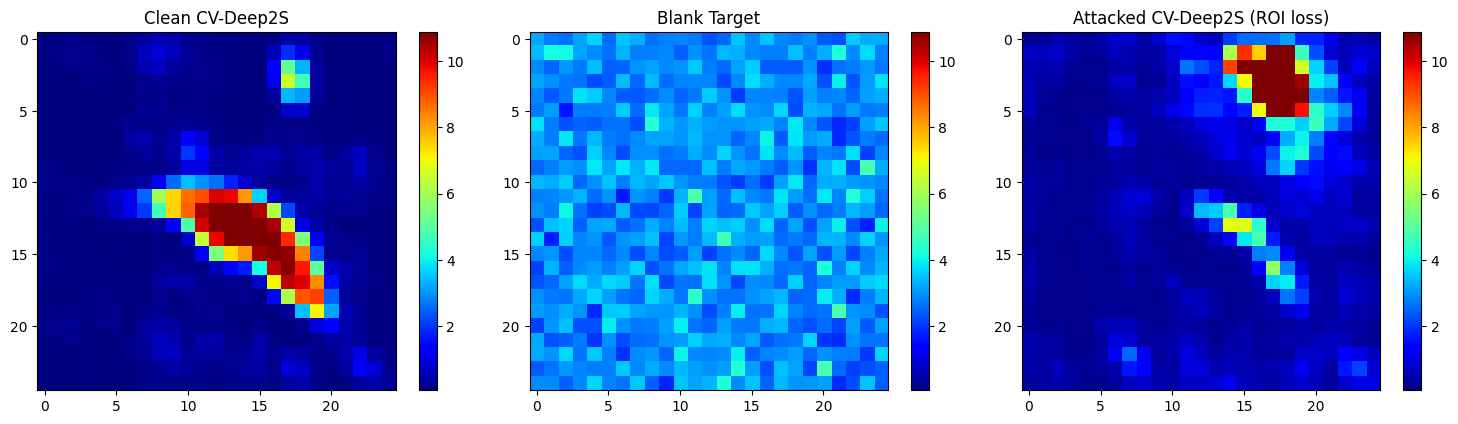

In [10]:
# ============================================================
# 9. Final attacked reconstruction and visualization
# ============================================================

# Get final A from Z
A_re_opt, A_im_opt = get_A_from_Z(Z_re, Z_im, Amax=Amax)
A_opt_tf  = tf.complex(A_re_opt, A_im_opt)            # (Np,)
A_opt_col = tf.reshape(A_opt_tf, (1, Np))             # (1,Np)

# Attacked measurements and reconstruction
Y_opt_flat_tf = X_v_flat_tf + D_flat * A_opt_col      # (K,Np)
Y_opt_tf      = tf.reshape(Y_opt_flat_tf, (1, K, T, R))

x_att_mag = cv_deep2s_forward_tf(Y_opt_tf).numpy()[0] # (X,Y,Z)

# MIP images
clean_mip   = x_clean_mag.max(axis=2)
att_mip     = x_att_mag.max(axis=2)
target_mip  = x_target.max(axis=2)

vmin = clean_mip.min()
vmax = clean_mip.max()

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(clean_mip, origin='upper', cmap='jet', vmin=vmin, vmax=vmax)
plt.title("Clean CV-Deep2S")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(target_mip, origin='upper', cmap='jet', vmin=vmin, vmax=vmax)
plt.title("Blank Target")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(att_mip, origin='upper', cmap='jet', vmin=vmin, vmax=vmax)
plt.title("Attacked CV-Deep2S (ROI loss)")
plt.colorbar()

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# 10. Global MIP-level quantitative evaluation
# ============================================================

mse_mip  = np.mean((att_mip - target_mip) ** 2)
rmse_mip = np.sqrt(mse_mip)
mae_mip  = np.mean(np.abs(att_mip - target_mip))

num = np.sum(att_mip * target_mip)
den = np.sqrt(np.sum(att_mip**2) * np.sum(target_mip**2)) + 1e-12
ncc_mip = num / den

data_range = float(target_mip.max() - target_mip.min() + 1e-12)
ssim_mip = ssim(att_mip, target_mip, data_range=data_range)
psnr_mip = psnr(target_mip, att_mip, data_range=data_range)

print("\n--- MIP-level attack metrics (global) ---")
print(f"MSE   : {mse_mip:.4e}")
print(f"RMSE  : {rmse_mip:.4e}")
print(f"MAE   : {mae_mip:.4e}")
print(f"NCC   : {ncc_mip:.4f}")
print(f"SSIM  : {ssim_mip:.4f}")
print(f"PSNR  : {psnr_mip:.2f} dB")

# ============================================================
# 11. ROI-only 3D evaluation
# ============================================================

roi_bool = roi_mask.astype(bool)
clean_roi = x_clean_mag[roi_bool]
att_roi   = x_att_mag[roi_bool]
tgt_roi   = x_target[roi_bool]

mse_clean_roi = np.mean((clean_roi - tgt_roi)**2)
mse_att_roi   = np.mean((att_roi   - tgt_roi)**2)

print("\n--- ROI-level (3D) MSE ---")
print(f"Clean vs target (ROI):   {mse_clean_roi:.4e}")
print(f"Attacked vs target (ROI): {mse_att_roi:.4e}")


--- MIP-level attack metrics (global) ---
MSE   : 1.1956e+01
RMSE  : 3.4577e+00
MAE   : 2.6127e+00
NCC   : 0.3982
SSIM  : -0.0042
PSNR  : -0.62 dB

--- ROI-level (3D) MSE ---
Clean vs target (ROI):   5.2481e+00
Attacked vs target (ROI): 8.9401e-01
